In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 1. Generate step-function dataset


In [2]:
torch.manual_seed(0)

N = 100
x = torch.linspace(-2, 2, N).reshape(-1, 1)

# Step function: y = 0 if x < 0, y = 1 if x >= 0
y = (x >= 0).float()

# Smooth grid for plotting
x_plot = torch.linspace(-2.5, 2.5, 100).reshape(-1, 1)
y_true_plot = (x_plot >= 0).float()

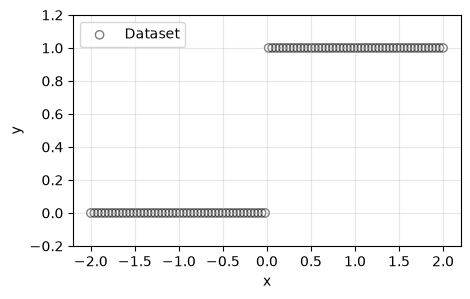

In [3]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, figsize=(5, 3))


# ------------------------------------------------------------
# 1) Linear regression fails
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

# ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10,loc='upper left')

plt.show()



In [4]:
# ============================================================
#  nonlinear features: phi(x) = [x, x^3]
# ============================================================

def cubic_feature(x):
    return torch.cat([x, x**3], dim=1)


feature_model    = nn.Linear(2, 1)
feature_optimizer = torch.optim.AdamW(feature_model.parameters(), lr=0.005)
mse_loss          = nn.MSELoss()


In [5]:

feature_loss_history = []

x_feature = cubic_feature(x)

for step in range(1000):
    logits  = feature_model(x_feature)
    loss    = mse_loss(logits, y)

    feature_optimizer.zero_grad()
    loss.backward()
    feature_optimizer.step()

    feature_loss_history.append(loss.item())

    print(f"Step {step+1:04d}: Loss = {loss.item():.4f}")

# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    x_plot_feature = cubic_feature(x_plot)
    y_feature_plot = feature_model(x_plot_feature)
    
    


Step 0001: Loss = 2.0273
Step 0002: Loss = 1.9829
Step 0003: Loss = 1.9396
Step 0004: Loss = 1.8972
Step 0005: Loss = 1.8558
Step 0006: Loss = 1.8154
Step 0007: Loss = 1.7760
Step 0008: Loss = 1.7377
Step 0009: Loss = 1.7004
Step 0010: Loss = 1.6642
Step 0011: Loss = 1.6290
Step 0012: Loss = 1.5949
Step 0013: Loss = 1.5618
Step 0014: Loss = 1.5298
Step 0015: Loss = 1.4989
Step 0016: Loss = 1.4689
Step 0017: Loss = 1.4400
Step 0018: Loss = 1.4122
Step 0019: Loss = 1.3853
Step 0020: Loss = 1.3594
Step 0021: Loss = 1.3346
Step 0022: Loss = 1.3106
Step 0023: Loss = 1.2876
Step 0024: Loss = 1.2655
Step 0025: Loss = 1.2444
Step 0026: Loss = 1.2240
Step 0027: Loss = 1.2045
Step 0028: Loss = 1.1859
Step 0029: Loss = 1.1680
Step 0030: Loss = 1.1508
Step 0031: Loss = 1.1343
Step 0032: Loss = 1.1186
Step 0033: Loss = 1.1034
Step 0034: Loss = 1.0889
Step 0035: Loss = 1.0750
Step 0036: Loss = 1.0616
Step 0037: Loss = 1.0487
Step 0038: Loss = 1.0363
Step 0039: Loss = 1.0244
Step 0040: Loss = 1.0128


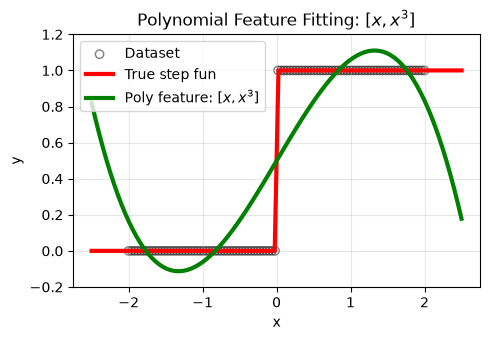

In [6]:
# ============================================================
# 5. Visualization: dataset + polynomial feature fitting
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(5, 3.5))

# ------------------------------------------------------------
# 1) Polynomial feature fitting
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",
    edgecolors="black",
    alpha=0.5,
    label="Dataset",
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun",
)

ax.plot(
    x_plot.numpy(),
    y_feature_plot.numpy(),
    color="green",
    linewidth=3,
    label=r"Poly feature: $[x, x^3]$",
)

ax.set_title(r"Polynomial Feature Fitting: $[x, x^3]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


plt.tight_layout()
fig.savefig("reg2-poly-feature.png", dpi=300, bbox_inches="tight")
plt.show()